In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('climate_data_aggregated_by_month_and_district.csv')

In [4]:
df

,feature,month,tp,e,ro,t2m,stl1,d2m,stl2,swvl1,swvl2,cvh,cvl,slt
0,A & N Islands_Nicobars,1,0.155895,-0.145155,0.000000,299.957974,301.395849,296.205143,301.395933,7.828219e-07,9.263556e-07,0.000000,0.000000,0.00
1,A & N Islands_Nicobars,2,0.073241,-0.127951,0.000000,300.347773,301.663718,296.253400,301.655300,-1.457989e-06,-8.020846e-08,0.000000,0.000000,0.00
2,A & N Islands_Nicobars,3,0.107033,-0.118626,0.000000,300.728570,302.288358,296.591939,302.276559,-1.509114e-06,-8.345849e-07,0.000000,0.000000,0.00
3,A & N Islands_Nicobars,4,0.134209,-0.101045,0.000000,300.984711,302.984163,297.179667,302.976795,-2.279712e-07,2.165511e-06,0.000000,0.000000,0.00
4,A & N Islands_Nicobars,5,0.265185,-0.136944,0.000000,300.947370,302.708544,297.735900,302.719828,3.265345e-07,-1.801931e-06,0.000000,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9271,West Bengal_Purulia,8,0.286655,-0.108605,0.091595,301.316108,301.991658,298.498164,301.356652,4.016572e-01,4.017722e-01,0.317097,0.668795,2.25
9272,West Bengal_Purulia,9,0.232007,-0.106522,0.097131,301.040230,301.816350,298.070948,301.156227,3.893341e-01,3.896617e-01,0.317097,0.668795,2.25
9273,West Bengal_Purulia,10,0.092837,-0.102173,0.072248,299.260643,300.044396,294.979955,299.625393,3.149695e-01,3.254036e-01,0.317097,0.668795,2.25
9274,West Bengal_Purulia,11,0.008047,-0.069953,0.029248,295.191450,296.073610,289.408941,296.285416,2.077455e-01,2.354825e-01,0.317097,0.668795,2.25


In [5]:
import pandas as pd
import numpy as np

def extract_climate_features(df):
    """
    Extract annual + seasonal agro-climate features for each district.

    Expected columns:
    feature, month, tp, e, ro, t2m, stl1, d2m, stl2, swvl1, swvl2, cvh, cvl, slt
    """

    df = df.copy()
    df['location'] = df['feature']

    # -----------------------------
    # Season mapping
    # -----------------------------
    season_map = {
        1: "rabi", 2: "zaid", 3: "zaid",
        4: "zaid", 5: "zaid",
        6: "kharif", 7: "kharif", 8: "kharif", 9: "kharif", 10: "rabi",
        11: "rabi", 12: "rabi"
    }

    df["season"] = df["month"].map(season_map)

    climate_vars = [
        "tp", "e", 
        #"ro", 
        #"t2m", 
        #"d2m",
        #"stl1", 
        #"stl2",
        "swvl1", 
        #"swvl2"
    ]

    results = []

    for location, group in df.groupby("location"):

        group = group.sort_values("month").reset_index(drop=True)
        feat = {"location": location}

        ## =========================================================
        ##    ORIGINAL MONTHLY VARIABLES (keep as features)
        ## =========================================================
        #for var in climate_vars:
        #    for i in range(12):
        #        feat[f"{var}_m{i+1}"] = group.loc[i, var]

        # =========================================================
        #    ANNUAL FEATURES
        # =========================================================
        #for var in climate_vars:
        #    vals = group[var].values

        #    feat[f"{var}_annual_mean"] = np.mean(vals)
        #    feat[f"{var}_annual_std"] = np.std(vals)
        #    feat[f"{var}_annual_max"] = np.max(vals)
        #    feat[f"{var}_annual_min"] = np.min(vals)
        #    #feat[f"{var}_annual_p90"] = np.percentile(vals, 90)
        #    #feat[f"{var}_annual_p10"] = np.percentile(vals, 10)

        #    #if var == "tp":
        #    #    feat["tp_annual_total"] = np.sum(vals)

        # =========================================================
        #    SEASONAL FEATURES
        # =========================================================
        for season in ["kharif", "rabi", "zaid"]:

            sgroup = group[group["season"] == season]

            for var in climate_vars:

                vals = sgroup[var].values
                if len(vals) == 0:
                    continue

                # Skip raw t2m and stl1 (we will replace them by difference)
                if var in ["t2m", "stl1"]:
                    continue

                feat[f"{var}_{season}_mean"] = np.mean(vals)
                feat[f"{var}_{season}_std"]  = np.std(vals)
                #feat[f"{var}_{season}_max"]  = np.max(vals)
                #feat[f"{var}_{season}_min"]  = np.min(vals)
            
            feat.pop(f"tp_zaid_std", None)
            feat.pop(f"tp_rabi_std", None)


            # ---------------------------------
            # Soil–Air Temperature Difference
            # ---------------------------------
            t2m_vals  = sgroup["t2m"].values
            stl1_vals = sgroup["stl1"].values

            if len(t2m_vals) > 0 and len(stl1_vals) > 0:

                diff = stl1_vals - t2m_vals

                feat[f"soil_air_diff_{season}_mean"] = np.mean(diff)
                feat[f"soil_air_diff_{season}_std"]  = np.std(diff)
                #feat[f"soil_air_diff_{season}_max"]  = np.max(diff)
                #feat[f"soil_air_diff_{season}_min"]  = np.min(diff)
            
            feat.pop(f"soil_air_diff_zaid_std", None)
            
            # ---------------------------------
            # Runoff ratio (ro / tp)
            # ---------------------------------
            tp_vals = sgroup["tp"].values
            ro_vals = sgroup["ro"].values

            if len(tp_vals) > 0:
                ratio = np.divide(
                    ro_vals,
                    tp_vals,
                    out=np.zeros_like(ro_vals),
                    where=tp_vals != 0
                )

                feat[f"runoff_ratio_{season}_mean"] = np.mean(ratio)
                #feat[f"runoff_ratio_{season}_std"]  = np.std(ratio)

        # =========================================================
        #    PRECIPITATION STRUCTURE FEATURES
        # =========================================================
        tp = group["tp"].values

        #feat["tp_amplitude"] = np.max(tp) - np.min(tp)

        # Peak month (cyclic encoding)
        #peak_month = group.loc[group["tp"].idxmax(), "month"]
        #feat["tp_peak_sin"] = np.sin(2 * np.pi * peak_month / 12)
        #feat["tp_peak_cos"] = np.cos(2 * np.pi * peak_month / 12)

        # PCI
        #tp_sum = np.sum(tp)
        #if tp_sum > 0:
        #    feat["tp_PCI"] = (np.sum(tp**2) / (tp_sum**2)) * 100
        #else:
        #    feat["tp_PCI"] = 0

        tp_sum = np.sum(tp)

        # rainfall variability (derived, more stable than amplitude/std)
        #feat["rainfall_variability"] = (
        #    np.std(tp) / (np.mean(tp) + 1e-6)
        #)

        # rainfall seasonality (monsoon dominance)
        #feat["tp_seasonality"] = (
        #    feat.get("tp_kharif_mean", 0) /
        #    (tp_sum + 1e-6)
        #)

        # rainfall concentration in kharif
        kharif_total = group[group["season"] == "kharif"]["tp"].sum()
        feat["tp_kharif_fraction"] = kharif_total / tp_sum if tp_sum > 0 else 0
        
        #ro_sum = np.sum(group["ro"].values)
        #feat["runoff_ratio_annual"] = ro_sum / tp_sum if tp_sum > 0 else 0

        # =========================================================
        #    TEMPERATURE FEATURES
        # =========================================================
        t2m = group["t2m"].values

        feat["t2m_amplitude"] = np.max(t2m) - np.min(t2m)

        peak_month = group.loc[group["t2m"].idxmax(), "month"]
        feat["t2m_peak_sin"] = np.sin(2 * np.pi * peak_month / 12)
        feat["t2m_peak_cos"] = np.cos(2 * np.pi * peak_month / 12)

        # Growing Degree Days (base = 10C = 283.15K)
        #feat["GDD_annual"] = np.sum(np.maximum(t2m - 283.15, 0))

        # seasonal GDD
        for season in ["kharif", "rabi", "zaid"]:
            svals = group[group["season"] == season]["t2m"].values
            if len(svals) > 0:
                feat[f"GDD_{season}"] = np.sum(np.maximum(svals - 283.15, 0))
        feat.pop("GDD_zaid", None)

        # heat stress months
        feat["heat_months_30C"] = np.sum(t2m > 303)
        feat["heat_months_35C"] = np.sum(t2m > 308)

        # =========================================================
        #    HUMIDITY INDEX
        # =========================================================
        feat["humidity_index_annual"] = np.mean(group["t2m"] - group["d2m"])

        feat["humidity_variability"] = np.std(group["t2m"] - group["d2m"])

        # =========================================================
        #    SOIL MOISTURE STRESS
        # =========================================================
        for var in ["swvl1", "swvl2"]:
            if var == "swvl1":
                vals = group[var].values
                feat[f"{var}_amplitude"] = np.max(vals) - np.min(vals)
        
        # soil moisture stability
        feat["swvl1_stability"] = (
            feat["swvl1_amplitude"] /
            (feat.get("swvl1_kharif_mean", 1e-6))
        )

        # seasonal contrast
        feat["soil_moisture_seasonality"] = (
            feat.get("swvl1_kharif_mean", 0) -
            feat.get("swvl1_rabi_mean", 0)
        )

        feat.pop("swvl1_zaid_mean", None)

        # =========================================================
        #    EVAPORATION / RAIN RATIO
        # =========================================================
        e_total = np.abs(group["e"].sum())
        feat["evap_rain_ratio"] = e_total / tp_sum if tp_sum > 0 else 0

        # =========================================================
        #    STATIC VARIABLES
        # =========================================================
        feat["cvh"] = group["cvh"].mode()[0]
        #feat["cvl"] = group["cvl"].mode()[0]
        #feat["slt"] = group["slt"].iloc[0]

        #feat["effective_rainfall_kharif"] = feat["tp_kharif_mean"] * (1 - feat["runoff_ratio_kharif_mean"])
        feat["water_retention_index"] = 1 - feat["runoff_ratio_kharif_mean"] - feat["evap_rain_ratio"]
        #feat["rainfall_seasonality_contrast"] = feat["tp_kharif_fraction"] - (feat["tp_rabi_mean"] / (feat["tp_rabi_mean"] + feat.get("tp_kharif_mean", 1e-6)))
        #feat["moisture_instability"] = (feat["swvl1_kharif_std"] + feat["humidity_variability"]) / 2
        feat["humidity_stress_index"] = feat["humidity_index_annual"] / (feat["humidity_variability"] + 1e-6)

        feat.pop("humidity_index_annual", None)
        feat.pop("swvl1_kharif_std", None)
        feat.pop("evap_rain_ratio", None)
        feat.pop("tp_rabi_mean", None)
        

        results.append(feat)

    return pd.DataFrame(results)


# =========================================================
# RUN FEATURE EXTRACTION
# =========================================================

features_df = extract_climate_features(df)

print(features_df.shape)
#view all columns
pd.set_option('display.max_columns', None)
features_df.head()

(773, 37)


,location,tp_kharif_mean,tp_kharif_std,e_kharif_mean,e_kharif_std,swvl1_kharif_mean,soil_air_diff_kharif_mean,soil_air_diff_kharif_std,runoff_ratio_kharif_mean,e_rabi_mean,e_rabi_std,swvl1_rabi_mean,swvl1_rabi_std,soil_air_diff_rabi_mean,soil_air_diff_rabi_std,runoff_ratio_rabi_mean,tp_zaid_mean,e_zaid_mean,e_zaid_std,swvl1_zaid_std,soil_air_diff_zaid_mean,runoff_ratio_zaid_mean,tp_kharif_fraction,t2m_amplitude,t2m_peak_sin,t2m_peak_cos,GDD_kharif,GDD_rabi,heat_months_30C,heat_months_35C,humidity_variability,swvl1_amplitude,swvl1_stability,soil_moisture_seasonality,cvh,water_retention_index,humidity_stress_index
0,A & N Islands_Nicobars,0.212075,0.009158,-0.144988,0.012498,5.571480e-07,1.401477,0.055918,0.000000,-0.124398,0.017050,9.293026e-07,3.383562e-07,1.671588,0.181726,0.000000,0.144917,-0.121142,0.013288,7.913001e-07,1.659090,0.000000,0.348657,1.134985,0.866025,-0.500000,69.329123,67.030034,0,0,0.403557,0.000005,9.164305,-3.721546e-07,0.000000,0.357962,8.448173
1,A & N Islands_North And Middle Andaman,0.337536,0.009329,-0.137305,0.010667,1.246314e-01,1.206633,0.090948,0.127147,-0.133948,0.013910,9.895371e-02,2.158417e-02,1.245317,0.131200,0.221187,0.092360,-0.119274,0.013720,2.435371e-02,1.654088,0.094867,0.605877,2.431255,0.866025,-0.500000,68.627663,66.739761,0,0,1.009721,0.082650,0.663154,2.567770e-02,0.097324,0.171858,3.615982
2,A & N Islands_South Andamans,0.311476,0.022785,-0.144685,0.010310,1.675441e-02,1.314073,0.136034,0.024587,-0.137583,0.018443,1.359085e-02,2.696283e-03,1.502017,0.180383,0.025422,0.111093,-0.122804,0.015493,3.548747e-03,1.650127,0.011569,0.536546,1.843473,0.866025,-0.500000,69.317921,67.797892,0,0,0.846505,0.010900,0.650601,3.163555e-03,0.009017,0.277637,4.320013
3,Andhra Pradesh_Alluri Sitharama Raju,0.312446,0.044864,-0.094966,0.003045,3.896810e-01,0.550737,0.154662,0.452236,-0.079284,0.017084,2.657519e-01,6.866067e-02,0.433444,0.106200,0.774702,0.043297,-0.077587,0.018399,3.343124e-02,1.084763,0.211140,0.752884,8.343844,0.500000,-0.866025,64.476528,50.285603,0,0,1.968619,0.238318,0.611573,1.239291e-01,0.737434,-0.059075,2.707588
4,Andhra Pradesh_Anakapalli,0.228586,0.028609,-0.107531,0.002641,2.852737e-01,0.548313,0.174455,0.237716,-0.086047,0.017171,1.918294e-01,5.604025e-02,1.020859,0.200021,0.441470,0.029884,-0.075685,0.012606,1.595826e-02,1.485763,0.166028,0.706428,7.859465,0.500000,-0.866025,72.360875,56.039035,1,0,0.958582,0.191011,0.669571,9.344429e-02,0.403020,-0.069854,4.945039


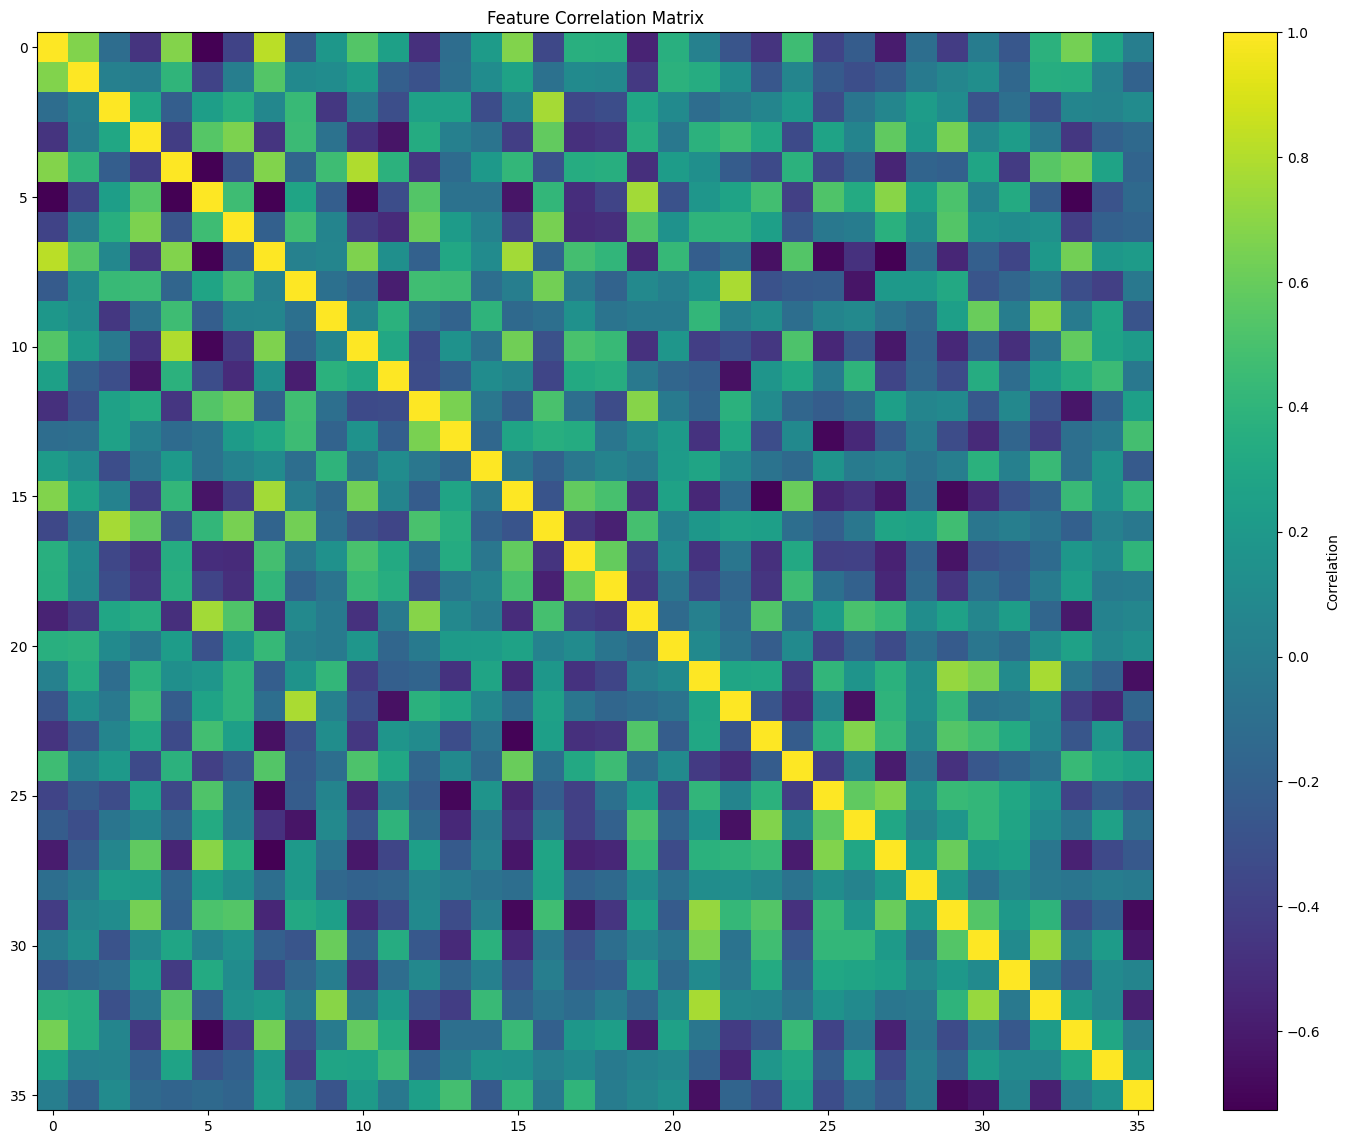

In [6]:
import numpy as np
import pandas as pd

corr_matrix = features_df.drop(columns=["location"]).corr()

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar(label="Correlation")
plt.title("Feature Correlation Matrix")
plt.show()

In [7]:
corr_matrix.to_csv('feature_correlation_matrix.csv', index=True)

In [8]:
# view top pairs of correlated features which arent reflexive relations
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:  # threshold for high correlation
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

# sort by absolute correlation value
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

# display top correlated pairs
for pair in corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.5f}")

tp_kharif_mean - runoff_ratio_kharif_mean: 0.81896


In [9]:
# numver of highly correlated pairs
len(corr_pairs)

1

In [10]:
# most redundant features (appearing most in these pairs)
from collections import Counter
feature_counts = Counter()

for pair in corr_pairs:
    feature_counts[pair[0]] += 1
    feature_counts[pair[1]] += 1

print(feature_counts.most_common(20))

[('tp_kharif_mean', 1), ('runoff_ratio_kharif_mean', 1)]


In [11]:
features_df.to_csv('engineered_climate_features_slight_correlation.csv', index=False)

In [12]:
# all feature names alphabetically
feature_names = sorted([col for col in features_df.columns if col != "location"])
for name in feature_names:
    print(name)

GDD_kharif
GDD_rabi
cvh
e_kharif_mean
e_kharif_std
e_rabi_mean
e_rabi_std
e_zaid_mean
e_zaid_std
heat_months_30C
heat_months_35C
humidity_stress_index
humidity_variability
runoff_ratio_kharif_mean
runoff_ratio_rabi_mean
runoff_ratio_zaid_mean
soil_air_diff_kharif_mean
soil_air_diff_kharif_std
soil_air_diff_rabi_mean
soil_air_diff_rabi_std
soil_air_diff_zaid_mean
soil_moisture_seasonality
swvl1_amplitude
swvl1_kharif_mean
swvl1_rabi_mean
swvl1_rabi_std
swvl1_stability
swvl1_zaid_std
t2m_amplitude
t2m_peak_cos
t2m_peak_sin
tp_kharif_fraction
tp_kharif_mean
tp_kharif_std
tp_zaid_mean
water_retention_index
